# First analysis of dataset

In [65]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ysights import *
import networkx as nx

In [2]:
db_path = 'data/1k_60d_FollowerPopularity_BA_database.db'

## Using ***sqlite3***

In [3]:
# database connection
conn = sqlite3.connect(db_path)

# List available tables
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)
print(tables)

               name
0   sqlite_sequence
1          hashtags
2     post_hashtags
3          mentions
4          emotions
5     post_emotions
6            rounds
7            follow
8         reactions
9          websites
10         articles
11  recommendations
12           voting
13    user_interest
14        interests
15      post_topics
16        user_mgmt
17           images
18             post
19   article_topics
20   post_sentiment
21    post_toxicity


### Database and tables exploration

**Database description:**
- user_mgmt: contains the agents’ metadata;
- articles: contains the news articles that agents shared;
- websites: contains the websites whose articles shared by the agents;
- emotions: contains the emotions that contents can elicit;
- follow: contains the social connections between agents;
- hashtags: contains the hashtags used by agents;
- images: contains the images (along with their LLM textual annotation) shared by agents;
- post: contains the posts/comments shared by agents;
- post_emotions: contains the emotions elicited by agents’ contents;
- post_hashtags: contains the hashtags used by agents in their contents;
- post_sentiment: contains the VADER sentiment annotations of agents’ generated contents;
- post_toxicity: contains the Perspective API toxicity annotations of agents’ generated contents;
- post_topics: contains the topics (i.e., interests) of agents’ generated contents;
- interests: contains the interests (i.e., topics) used in the simulation;
- user_interest: contains the interests (i.e., topics) used by agents to generate content;
- voting: contains the votes cast by agents (if the “cast” action is enabled);
- mentions: contains the mentions between agents;
- reactions: contains the reactions to agents contents;
- recommendations: contains the content recommendations provided by the server to agents;
- rounds: contains the simulation rounds.

5 of these tables are empty (articles, websites, images, post_toxicity, voting).

In [5]:
print(pd.read_sql("SELECT COUNT(id) FROM user_mgmt;", conn))
pd.read_sql("SELECT * FROM user_mgmt LIMIT 5;", conn)

   COUNT(id)
0        994


,id,username,email,password,user_type,leaning,age,oe,co,ex,...,joined_on,frecsys_type,round_actions,gender,nationality,toxicity,is_page,left_on,daily_activity_level,profession
0,1,Admin,admin@ysocial.com,pbkdf2:sha256:260000$tjP4Gh0VVkutjhoM$89a93257...,user,none,0,None,None,None,...,0,default,3,None,None,none,0,None,1,None
1,2,Mrs.KimberlyWard,Mrs.KimberlyWard@ysocial.it,Mrs.KimberlyWard,sushruth/solar-uncensored:latest,democrat,48,consistent/cautious,extravagant/careless,outgoing/energetic,...,1,PreferentialAttachment,2,female,American,high,0,None,3,Athlete
2,3,WilliamCruz,WilliamCruz@ysocial.it,WilliamCruz,sushruth/solar-uncensored:latest,republican,26,inventive/curious,efficient/organized,outgoing/energetic,...,1,PreferentialAttachment,2,male,American,low,0,None,1,Blacksmith
3,4,KellyGonzalez,KellyGonzalez@ysocial.it,KellyGonzalez,sushruth/solar-uncensored:latest,republican,46,inventive/curious,efficient/organized,outgoing/energetic,...,1,PreferentialAttachment,3,female,American,none,0,None,2,Dentist
4,5,TiffanyArroyo,TiffanyArroyo@ysocial.it,TiffanyArroyo,sushruth/solar-uncensored:latest,democrat,49,inventive/curious,extravagant/careless,outgoing/energetic,...,1,PreferentialAttachment,1,female,American,low,0,None,3,Fast Food Worker


In [6]:
print(pd.read_sql("SELECT COUNT(id) FROM articles;", conn))
pd.read_sql("SELECT * FROM articles LIMIT 5;", conn)

   COUNT(id)
0          0


,id,title,summary,website_id,fetched_on,link


In [41]:
print(pd.read_sql("SELECT COUNT(id) FROM websites;", conn))
pd.read_sql("SELECT * FROM websites LIMIT 5;", conn)

   COUNT(id)
0          0


,id,name,rss,leaning,category,last_fetched,country,language


In [40]:
print(pd.read_sql("SELECT COUNT(id) FROM emotions;", conn))
pd.read_sql("SELECT * FROM emotions LIMIT 5;", conn)

   COUNT(id)
0         28


,id,emotion,icon
0,1,amusement,mdi-emoticon-happy
1,2,admiration,mdi-weather-sunny
2,3,anger,mdi-emoticon-devil
3,4,annoyance,mdi-emoticon-tongue
4,5,approval,mdi-thumb-up-outline


In [39]:
print(pd.read_sql("SELECT COUNT(id) FROM follow;", conn))
pd.read_sql("SELECT * FROM follow LIMIT 5;", conn)

   COUNT(id)
0      59435


,user_id,follower_id,id,action,round
0,2,3,1,follow,0
1,2,4,2,follow,0
2,2,5,3,follow,0
3,2,6,4,follow,0
4,2,7,5,follow,0


In [34]:
print(pd.read_sql("SELECT COUNT(id) FROM hashtags;", conn))
pd.read_sql("SELECT * FROM hashtags LIMIT 5;", conn)

   COUNT(id)
0      53069


,hashtag,id
0,#Tech,1
1,#ThursdayThoughts,2
2,#FutureofDigitalActivism,3
3,#InnovationMatters,4
4,#TechnologyProgress,5


In [33]:
print(pd.read_sql("SELECT COUNT(id) FROM images;", conn))
pd.read_sql("SELECT * FROM images LIMIT 5;", conn)

   COUNT(id)
0          0


,id,url,description,article_id


In [32]:
print(pd.read_sql("SELECT COUNT(id) FROM post;", conn))
pd.read_sql("SELECT * FROM post LIMIT 5;", conn)

   COUNT(id)
0      71486


,id,tweet,post_img,user_id,comment_to,thread_id,round,news_id,shared_from,image_id,reaction_count
0,1,Am seriously amazed by how #Tech has evolved &...,None,298,-1,1,1,None,-1,None,3
1,2,Just discovered the newest productivity app & ...,None,813,-1,2,1,None,-1,None,1
2,3,@DanielHenry Technology has completely reshape...,None,813,1,1,1,None,-1,None,1
3,4,"@EmmaPatel That's impressive, Ms.Patel 😊 I per...",None,857,2,2,1,None,-1,None,3
4,5,@EmmaPatel Exciting times indeed that we live ...,None,857,1,1,1,None,-1,None,2


In [31]:
print(pd.read_sql("SELECT COUNT(id) FROM post_emotions;", conn))
pd.read_sql("SELECT * FROM post_emotions LIMIT 5;", conn)

   COUNT(id)
0     102400


,id,post_id,emotion_id
0,1,1,2
1,2,1,9
2,3,1,14
3,4,1,21
4,5,2,1


In [30]:
print(pd.read_sql("SELECT COUNT(id) FROM post_hashtags;", conn))
pd.read_sql("SELECT * FROM post_hashtags LIMIT 5;", conn)

   COUNT(id)
0      82929


,post_id,hashtag_id,id
0,1,1,1
1,1,2,2
2,1,3,3
3,3,4,4
4,3,5,5


In [29]:
print(pd.read_sql("SELECT COUNT(id) FROM post_sentiment;", conn))
pd.read_sql("SELECT * FROM post_sentiment LIMIT 5;", conn)

   COUNT(id)
0     187433


,id,post_id,neg,pos,neu,compound,user_id,round,sentiment_parent,topic_id,is_post,is_comment,is_reaction
0,1,1,0.06,0.124,0.816,0.4199,298,1,,11,1,0,0
1,2,2,0.00,0.344,0.656,0.9115,813,1,,14,1,0,0
2,3,3,0.00,0.229,0.771,0.8225,813,1,pos,11,0,1,0
3,4,1,0.00,1.000,0.000,1.0000,813,1,pos,11,0,0,1
4,5,4,0.00,0.326,0.674,0.9186,857,1,pos,14,0,1,0


In [28]:
print(pd.read_sql("SELECT COUNT(id) FROM post_toxicity;", conn))
pd.read_sql("SELECT * FROM post_toxicity LIMIT 5;", conn)

   COUNT(id)
0          0


,id,post_id,toxicity,severe_toxicity,identity_attack,insult,profanity,threat,sexually_explicit,flirtation


In [27]:
print(pd.read_sql("SELECT COUNT(id) FROM post_topics;", conn))
pd.read_sql("SELECT * FROM post_topics LIMIT 5;", conn)

   COUNT(id)
0      20427


,id,post_id,topic_id
0,1,1,11
1,2,2,14
2,3,12,4
3,4,12,2
4,5,16,4


In [26]:
print(pd.read_sql("SELECT COUNT(iid) FROM interests;", conn))
pd.read_sql("SELECT * FROM interests LIMIT 5;", conn)

   COUNT(iid)
0          15


,iid,interest
0,1,Weekend Routines
1,2,Influencer Responsibility
2,3,Dating Apps
3,4,Cancel Culture
4,5,Creative Projects


In [23]:
print(pd.read_sql("SELECT COUNT(id) FROM user_interest;", conn))
pd.read_sql("SELECT * FROM user_interest LIMIT 5;", conn)

   COUNT(id)
0     123093


,id,user_id,interest_id,round_id
0,1,2,1,1
1,2,2,2,1
2,3,2,3,1
3,4,3,4,1
4,5,3,5,1


In [18]:
print(pd.read_sql("SELECT COUNT(vid) FROM voting;", conn))
pd.read_sql("SELECT * FROM voting LIMIT 5;", conn)

   COUNT(vid)
0           0


,vid,round,user_id,preference,content_type,content_id


In [15]:
print(pd.read_sql("SELECT COUNT(id) FROM mentions;", conn))
pd.read_sql("SELECT * FROM mentions LIMIT 5;", conn)

   COUNT(id)
0      50630


,id,user_id,post_id,round,answered
0,1,298,3,1,1
1,2,813,4,1,0
2,3,813,5,1,0
3,4,857,6,1,1
4,5,298,6,1,1


In [14]:
print(pd.read_sql("SELECT COUNT(id) FROM reactions;", conn))
pd.read_sql("SELECT * FROM reactions LIMIT 5;", conn)

   COUNT(id)
0      35342


,id,post_id,user_id,type,round
0,1,1,813,like,1
1,2,2,857,like,1
2,3,1,857,like,1
3,4,3,545,like,1
4,5,5,545,like,1


In [13]:
print(pd.read_sql("SELECT COUNT(id) FROM recommendations;", conn))
pd.read_sql("SELECT * FROM recommendations LIMIT 5;", conn)

   COUNT(id)
0      44557


,id,user_id,post_ids,round
0,1,813,1,1
1,2,857,3|2|1,1
2,3,857,3|2|3|2|1,1
3,4,860,5|4|3|2,1
4,5,545,6|5|4|3,1


In [12]:
print(pd.read_sql("SELECT COUNT(id) FROM rounds;", conn))
print(pd.read_sql("SELECT COUNT(id) FROM rounds WHERE day=0;", conn))
print(pd.read_sql("SELECT COUNT(id) FROM rounds WHERE day=23;", conn))
print(pd.read_sql("SELECT COUNT(id) FROM rounds WHERE day=45;", conn))
print(pd.read_sql("SELECT COUNT(id) FROM rounds WHERE day=59;", conn))
print(pd.read_sql("SELECT COUNT(DISTINCT day) FROM rounds;", conn))
pd.read_sql("SELECT * FROM rounds LIMIT 5;", conn)

   COUNT(id)
0       1444
   COUNT(id)
0         34
   COUNT(id)
0         24
   COUNT(id)
0         24
   COUNT(id)
0         18
   COUNT(DISTINCT day)
0                   60


,id,day,hour
0,1,0,0
1,2,0,1
2,3,0,2
3,4,0,3
4,5,0,4


In table *rounds* there are 60 days and 1444 rounds. Usually 1 round = 1 hour. The first and the last days are exceptions.

However, as we can see not all tables have the same number of rounds. Possible that not in every round there is an action.

In [6]:
# check number of rounds in post
pd.read_sql("SELECT COUNT(DISTINCT ROUND) FROM post;", conn)

,COUNT(DISTINCT ROUND)
0,1359


In [7]:
# check number of rounds in follow
pd.read_sql("SELECT COUNT(DISTINCT ROUND) FROM follow;", conn)

,COUNT(DISTINCT ROUND)
0,1360


**Summary**

🔹 **Kluczowe tabele dla Twojej analizy:**

user_mgmt
→ Fundament Twojej analizy.
Zawiera metadane o agentach: typ użytkownika, ideologia (leaning), cechy osobowości (co, ex, ag, ne – zapewne Big Five), zainteresowania, poziom edukacji itp.
Umożliwia identyfikację person i grup agentów, które potem możesz zestawiać z ich pozycją w sieci.

follow
→ Najważniejsza strukturalnie tabela.
Zawiera połączenia między agentami (user_id – followed_id) oraz ewentualną akcję i rundę symulacji.
To właśnie z niej zbudujesz graf relacji (sieć społecznościową).
Możesz obliczać: centralność, modularność, asortatywność, rdzeń–peryferie, k-core, itp.

mentions i reactions
→ Kluczowe do modelowania interakcji dynamicznych.

mentions pozwala zbudować graf komunikacji (kto z kim rozmawia).

reactions (np. „like”, „share”) daje wagę krawędzi (intensywność relacji).
Dzięki temu możesz analizować warstwę interakcji (obok followerów).

post
→ Ważna warstwa pośrednia między agentem a siecią.
Zawiera treści generowane przez agentów, identyfikatory użytkowników, emocje, itp.
Możesz z niej wyciągnąć liczbę postów, rytm aktywności, poziom zaangażowania, czyli indywidualne wskaźniki zachowań.

recommendations (opcjonalnie, ale wartościowa)
→ Pokazuje, jaki content był rekomendowany poszczególnym agentom.
Pozwala badać ekspozycję i jej wpływ na pozycję w sieci (ważne, jeśli chcesz zahaczyć o przyczynowość / dynamikę rewiringu).

🔸 **Tabele pomocnicze (możesz uwzględnić, ale nie są centralne):**

emotions, post_emotions, post_sentiment – jeśli chcesz analizować ton emocjonalny komunikacji (np. polaryzacja afektywna).

interests, post_topics, user_interest – mogą posłużyć do analizy homofilii tematycznej.

rounds – przydatne do analizy dynamiki w czasie (np. stabilność pozycji w kolejnych rundach).

🔹 **Sugerowane połączenie dla Twojej analizy:**

Sieć główna: follow lub mentions

Atrybuty węzłów: z user_mgmt

Wagi krawędzi / aktywność: z reactions

Czas / zmiany: z rounds

🔹 **Najważniejsze dla Twojego celu:**

👉 user_mgmt + follow + mentions (+ reactions)
To cztery tabele, które w pełni wystarczą do zbadania:

różnic w pozycji sieciowej między grupami (np. ideologia, osobowość),

stabilności pozycji w czasie (jeśli rounds jest aktywne),

identyfikowalności agentów po wzorcach interakcji (sygnatura strukturalna).

### Follow analysis

In [49]:
# check number of followings
follow_sum = pd.read_sql("SELECT COUNT(id) as follow_sum FROM follow;", conn)
follow_init = pd.read_sql("SELECT COUNT(id) as follow_init FROM follow WHERE round=0;", conn)
print(f"Followings in round 0: {follow_init['follow_init']}\n"
      f"Followings at the end: {follow_sum['follow_sum']}\n"
      f"New followings in 60 days: {follow_sum['follow_sum'] - follow_init['follow_init']}")

Followings in round 0: 0    29536
Name: follow_init, dtype: int64
Followings at the end: 0    59435
Name: follow_sum, dtype: int64
New followings in 60 days: 0    29899
dtype: int64


In [21]:
# check number of users
pd.read_sql("SELECT COUNT(DISTINCT user_id) FROM follow;", conn)

,COUNT(DISTINCT user_id)
0,993


#### Visualization

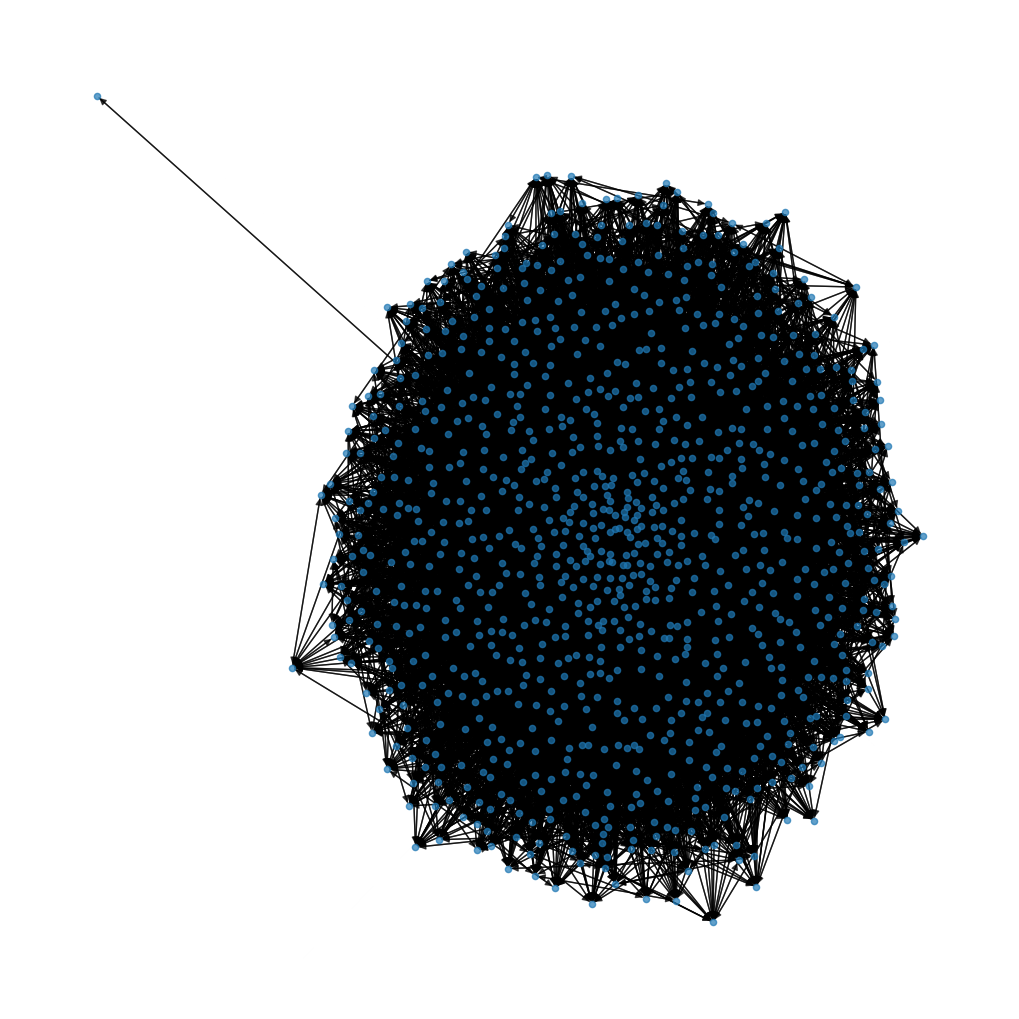

In [14]:
# initial graph
follow_0 = pd.read_sql("SELECT * FROM follow WHERE round=0;", conn)

G = nx.from_pandas_edgelist(follow_0, source="follower_id", target="user_id", create_using=nx.DiGraph())

plt.figure(figsize=(10, 10))
pos = nx.spring_layout(G, k=0.15)  # layout algorithm
nx.draw(G, pos, node_size=20, alpha=0.7, with_labels=False)
plt.show()

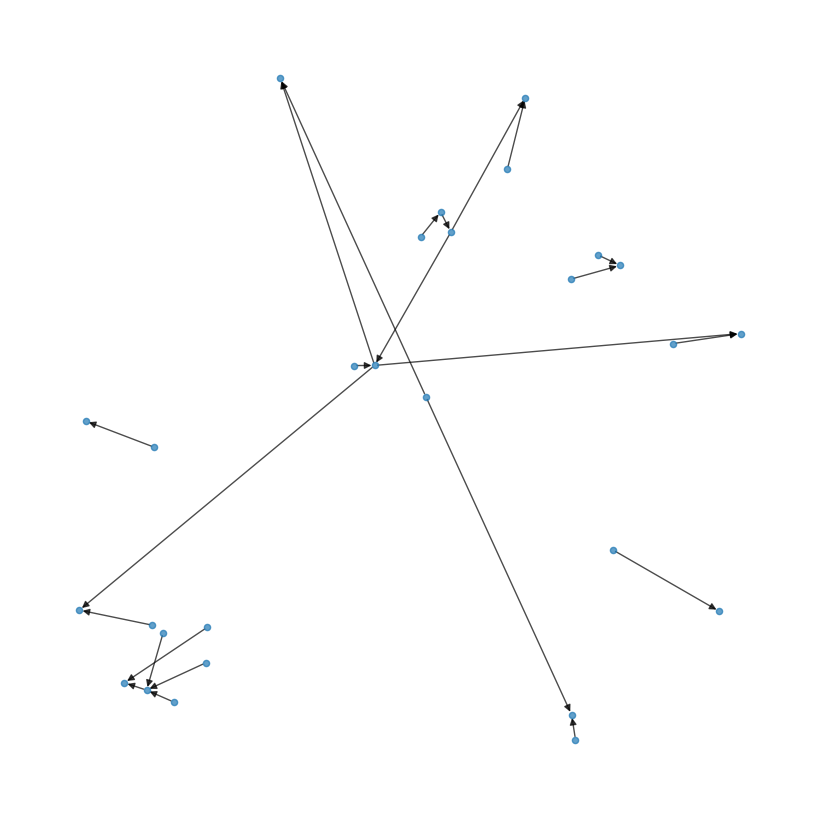

In [22]:
# example round -> the last one
follow_1359 = pd.read_sql("SELECT * FROM follow WHERE round=1359;", conn)

G = nx.from_pandas_edgelist(follow_1359, source="follower_id", target="user_id", create_using=nx.DiGraph())

plt.figure(figsize=(8, 8))
pos = nx.spring_layout(G, k=0.15)  # layout algorithm
nx.draw(G, pos, node_size=20, alpha=0.7, with_labels=False)
plt.show()

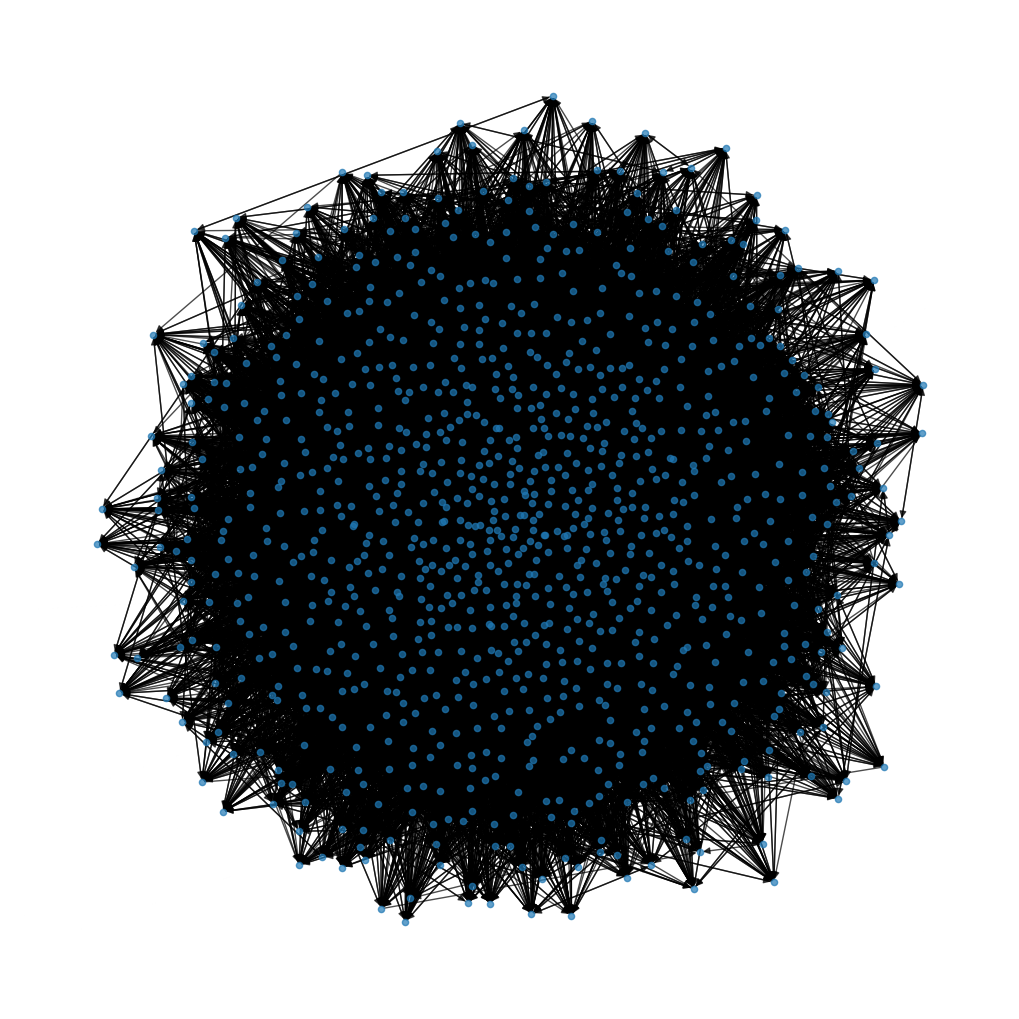

In [51]:
# final graph
follow = pd.read_sql("SELECT * FROM follow;", conn)

G_follow = nx.from_pandas_edgelist(follow, source="follower_id", target="user_id", create_using=nx.DiGraph())

plt.figure(figsize=(10, 10))
pos = nx.spring_layout(G_follow, k=0.15)  # layout algorithm
nx.draw(G_follow, pos, node_size=20, alpha=0.7, with_labels=False)
plt.show()

In [86]:
avg_deg = sum(dict(G_follow.degree()).values()) / G_follow.number_of_nodes()
dens = nx.density(G_follow)
diam = nx.diameter(G_follow.to_undirected()) # Longest shortest path between any two nodes
print(f"Mean degree: {avg_deg:.2f}, Density: {dens:.4f}, Diameter: {diam}")

Mean degree: 118.55, Density: 0.0598, Diameter: 3


#### Degree

Degree = number of connections per node.

In-degree → number of followers (how many follow me)

Out-degree → number of people I follow.

Weighted degree = same, but if edges had weights (e.g., number of interactions). # maybe later

In [56]:
# For directed graphs:
in_deg = dict(G_follow.in_degree())
out_deg = dict(G_follow.out_degree())

# Convert to dataframe
deg_df = pd.DataFrame({
    'node': list(G_follow.nodes()),
    'in_degree': [in_deg.get(n, 0) for n in G_follow.nodes()],
    'out_degree': [out_deg.get(n, 0) for n in G_follow.nodes()],
    'total_degree': [in_deg.get(n, 0) + out_deg.get(n, 0) for n in G_follow.nodes()]
})

print(f"Mean total degree: {deg_df['total_degree'].mean()}\n"
      f"Mean in_degree: {deg_df['in_degree'].mean()}\n"
      f"Mean out_degree: {deg_df['out_degree'].mean()}\n")

print(f"Median total degree: {deg_df['total_degree'].median()}\n"
      f"Median in_degree: {deg_df['in_degree'].median()}\n"
      f"Median out_degree: {deg_df['out_degree'].median()}\n")

deg_df.sort_values('total_degree', ascending=False).head()

Mean total degree: 118.54783484390735
Mean in_degree: 59.273917421953676
Mean out_degree: 59.273917421953676

Median total degree: 101.0
Median in_degree: 50.0
Median out_degree: 51.0



,node,in_degree,out_degree,total_degree
17,19,211,217,428
16,18,210,210,420
19,21,206,194,400
18,20,191,197,388
384,27,190,191,381


#### Centrality

- Betweenness centrality - Measures how often a node lies on shortest paths between other nodes. High betweenness → “bridge” nodes connecting communities.
- Eigenvector centrality - Measures influence based on connections to other influential nodes. Think “a node is important if it’s connected to other important nodes”.

In [60]:
bet = nx.betweenness_centrality(G_follow)

eig = nx.eigenvector_centrality_numpy(G_follow)

centrality_df = pd.DataFrame({
    'node': list(G_follow.nodes()),
    'betweenness': [bet.get(n, 0) for n in G_follow.nodes()],
    'eigenvector': [eig.get(n, 0) for n in G_follow.nodes()],
})
centrality_df.head()

,node,betweenness,eigenvector
0,3,0.003796,0.053756
1,2,0.007611,0.081810
2,4,0.002476,0.051097
3,5,0.000770,0.028380
4,6,0.003366,0.053419


#### K-core (rdzeń sieci) — using igraph

The k-core is the maximal subgraph where each node has at least k connections.
Nodes with higher core numbers are more centrally embedded in the network.

In [61]:
import igraph as ig

# Convert from networkx to igraph
ig_graph = ig.Graph.TupleList(G_follow.edges(), directed=True)

# Compute core numbers (k-shell decomposition)
core_numbers = ig_graph.coreness(mode="ALL")

# Attach to dataframe
kcore_df = pd.DataFrame({
    'node': ig_graph.vs['name'],
    'kcore': core_numbers
})
kcore_df.head()

,node,kcore
0,3,74
1,2,74
2,18,74
3,19,74
4,20,74


#### Community detection (Modularność / Społeczności) — Leiden Algorithm

Communities are clusters of nodes more connected internally than externally.
The Leiden algorithm (improved Louvain) finds such groups and the modularity score quantifies how good the division is (0–1 scale).

In [63]:
import leidenalg as la

# Using same igraph object

partition = la.find_partition(ig_graph, partition_type=la.ModularityVertexPartition)
modularity = partition.modularity

community_df = pd.DataFrame({
    'node': ig_graph.vs['name'],
    'community': partition.membership
})

print(f"Modularity score: {modularity:.3f}")
community_df.head()

Modularity score: 0.099


,node,community
0,3,8
1,2,3
2,18,3
3,19,5
4,20,5


#### Assortativity by persona (asortatywność względem persony)

Measures how strongly nodes connect to similar others based on a categorical or numeric attribute.
- Positive (close to +1): “birds of a feather” — users connect mostly to others with the same persona.
- Negative (close to -1): heterophily — users tend to connect with different personas.
- 0: no particular preference (random mixing).

In your case: “asortatywność względem persony” = tendency for users to follow others of the same persona type (e.g. student, journalist, bot, etc.)

In [ ]:
# more complicated :(

# ✅ Step 2 — create a dictionary
# persona_dict = dict(zip(personas['user_id'], personas['persona']))
#
#
# Now you have {1: 'student', 2: 'journalist', ...}
#
# ✅ Step 3 — assign personas as node attributes in your graph
# nx.set_node_attributes(G, persona_dict, 'persona')
#
# ✅ Step 4 — compute assortativity in NetworkX
# assort_persona = nx.attribute_assortativity_coefficient(G, 'persona')
# print(f"Asortatywność względem persony: {assort_persona:.3f}")
#
# 🧭 Interpretation
# Value	Interpretation
# > 0.3	Strong homophily (similar personas follow each other)
# 0.1–0.3	Mild tendency toward same persona
# ≈ 0	Random mixing
# < 0	Heterophily (opposite types connect)

#### Metrics analysis

In [64]:
metrics = (
    deg_df
    .merge(centrality_df, on='node', how='left')
    .merge(kcore_df, on='node', how='left')
    .merge(community_df, on='node', how='left')
)
metrics.head()

,node,in_degree,out_degree,total_degree,betweenness,eigenvector,kcore,community
0,3,122,119,241,0.003796,0.053756,74,8
1,2,171,189,360,0.007611,0.081810,74,3
2,4,110,102,212,0.002476,0.051097,74,0
3,5,60,64,124,0.000770,0.028380,74,0
4,6,120,122,242,0.003366,0.053419,74,1


In [66]:
metrics.describe()

,node,in_degree,out_degree,total_degree,betweenness,eigenvector,kcore,community
count,993.00000,993.000000,993.000000,993.000000,993.000000,993.000000,993.000000,993.000000
mean,498.00000,59.273917,59.273917,118.547835,0.001022,0.027442,66.927492,3.486405
std,286.79871,34.382243,31.748912,65.752530,0.001320,0.015945,9.600738,2.533658
min,2.00000,9.000000,17.000000,28.000000,0.000022,0.003984,28.000000,0.000000
25%,250.00000,34.000000,36.000000,70.000000,0.000265,0.015856,61.000000,1.000000
50%,498.00000,50.000000,51.000000,101.000000,0.000571,0.023244,73.000000,3.000000
75%,746.00000,74.000000,75.000000,148.000000,0.001206,0.034202,74.000000,6.000000
max,994.00000,211.000000,217.000000,428.000000,0.011050,0.099854,74.000000,8.000000


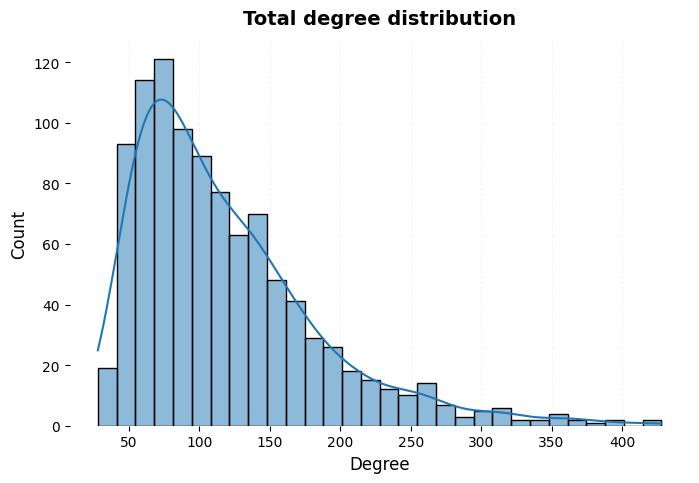

In [70]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(metrics['total_degree'], bins=30, kde=True, ax=ax) # color=sns.color_palette("pastel")[0]
ax.set_title("Total degree distribution", fontsize=14, weight="bold", pad=12)
ax.set_xlabel("Degree", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.grid(axis="x", linestyle="--", alpha=0.1)
sns.despine(left=True, bottom=True)
plt.show()

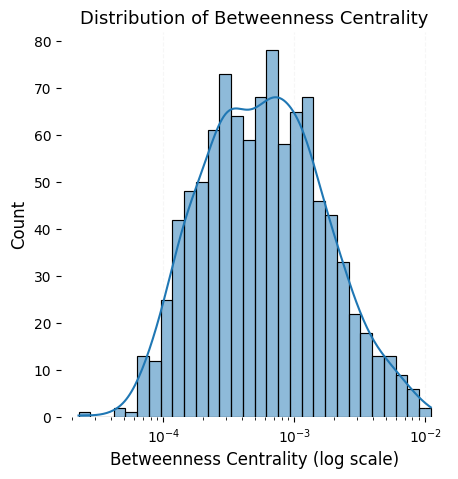

In [76]:
fig, ax = plt.subplots(figsize=(5, 5))
sns.histplot(metrics['betweenness'], bins=30, kde=True, log_scale=True, ax=ax)
ax.set_xlabel("Betweenness Centrality (log scale)", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title("Distribution of Betweenness Centrality", fontsize=13)
ax.grid(axis="x", linestyle="--", alpha=0.1)
sns.despine(left=True, bottom=True)
plt.show()

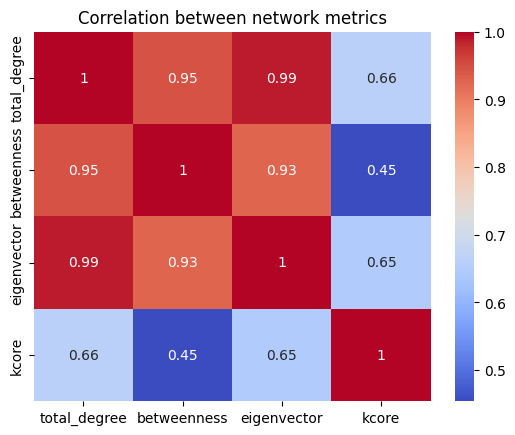

In [77]:
corr = metrics[['total_degree', 'betweenness', 'eigenvector', 'kcore']].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation between network metrics")
plt.show()


In [85]:
# Compare groups
metrics.groupby('community')['total_degree'].median().sort_values(ascending=False)

community
0    115.0
6    112.0
7    110.5
4    108.5
2    102.0
5     95.0
1     92.0
8     89.0
3     82.0
Name: total_degree, dtype: float64

## Using ***ysight***

In [2]:
# Initialize data handler
ydh = YDataHandler(db_path)

# Get simulation time range
time_range = ydh.time_range()
print(f"Simulation: rounds {time_range['min_round']} to {time_range['max_round']}")

# Get all agents
agents = ydh.agents()
print(f"Total agents: {len(agents.get_agents())}")

# Extract social network
network = ydh.social_network()
print(f"Network: {network.number_of_nodes()} nodes, {network.number_of_edges()} edges")

Simulation: rounds 1 to 1444
Total agents: 994
Network: 993 nodes, 58535 edges


In [7]:
# Look at the first agent
first_agent = agents.get_agents()[0]
print("\nFirst Agent Properties:")
print(f"  ID: {first_agent.id}")
print(f"  Age: {first_agent.age}")
print(f"  Gender: {first_agent.gender}")
print(f"  Education: {first_agent.education}")


First Agent Properties:
  ID: 1
  Age: 0
  Gender: 3
  Education: None


In [11]:
# Get agents with age 25
young_agents = ydh.agents_by_feature('age', 25)
print(f"Agents aged 25: {len(young_agents.get_agents())}")

# Get agents by gender
female_agents = ydh.agents_by_feature('gender', 'F')
print(f"Female agents: {len(female_agents.get_agents())}")

Agents aged 25: 22
Female agents: 0


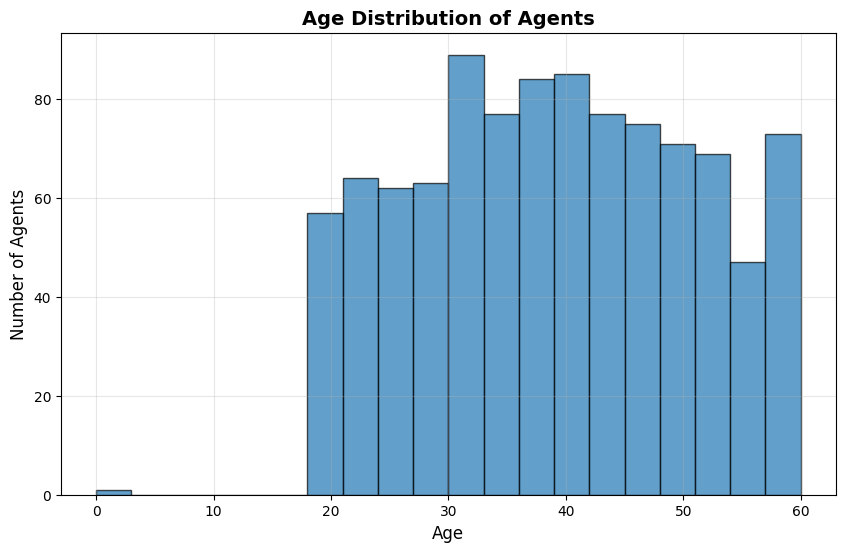

In [13]:
# Collect ages
ages = [agent.age for agent in agents.get_agents()]

# Plot age distribution
plt.figure(figsize=(10, 6))
plt.hist(ages, bins=20, edgecolor='black', alpha=0.7)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Number of Agents', fontsize=12)
plt.title('Age Distribution of Agents', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

In [15]:
# Get posts by a specific agent
agent_id = 857  # Change this to any valid agent ID
agent_posts = ydh.posts_by_agent(agent_id)

print(f"Agent {agent_id} created {len(agent_posts.get_posts())} posts")

# Examine the first post
if agent_posts.get_posts():
    first_post = agent_posts.get_posts()[0]
    print("\nFirst Post Details:")
    print(f"  Post ID: {first_post.id}")
    print(f"  Author: {first_post.user_id}")
    print(f"  Round: {first_post.round}")
    print(f"  Topic: {first_post.topics}")
    print(f"  Emotion: {first_post.emotions}")

Agent 857 created 158 posts

First Post Details:
  Post ID: 4
  Author: 857
  Round: 1
  Topic: []
  Emotion: []


In [16]:
# Get interest profile for an agent
agent_id = 1
profile = ydh.agent_interests(agent_id)

print(f"Interest Profile for Agent {agent_id}:")
for topic, score in list(profile.items())[:5]:  # Show top 5 topics
    print(f"  Topic {topic}: {score:.3f}")

Interest Profile for Agent 1:


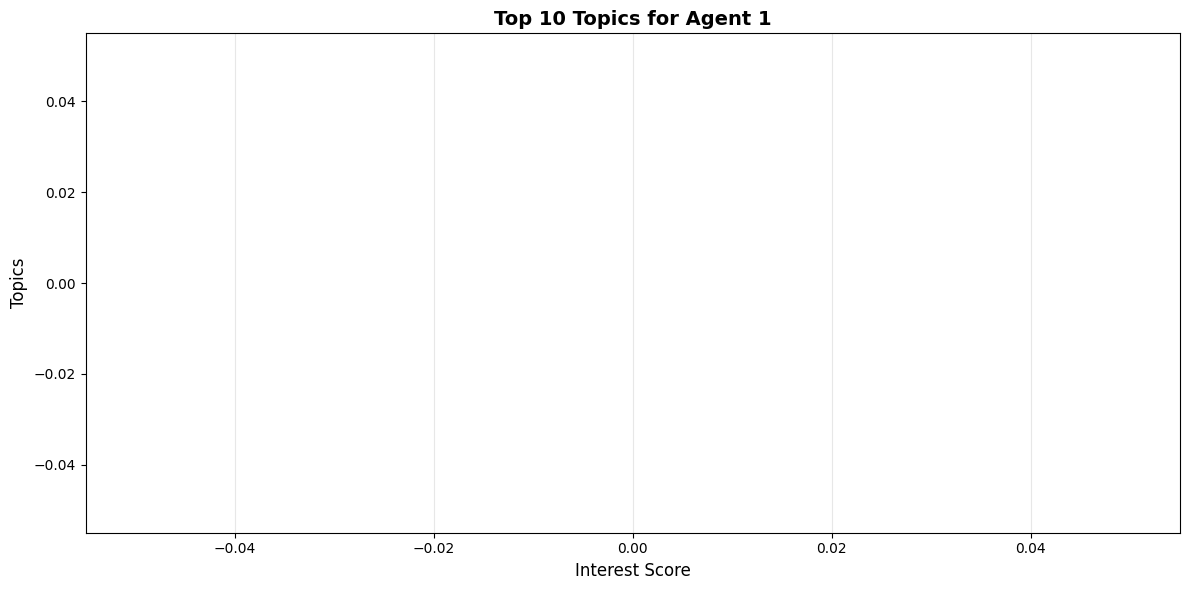

In [17]:
# Get top topics for visualization
sorted_topics = sorted(profile.items(), key=lambda x: x[1], reverse=True)[:10]
topics = [f"Topic {t[0]}" for t in sorted_topics]
scores = [t[1] for t in sorted_topics]

# Create bar plot
plt.figure(figsize=(12, 6))
plt.barh(topics, scores, color='steelblue', alpha=0.8)
plt.xlabel('Interest Score', fontsize=12)
plt.ylabel('Topics', fontsize=12)
plt.title(f'Top 10 Topics for Agent {agent_id}', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

In [18]:
# Example: Get top 5 most active agents
query = """
    SELECT user_id, COUNT(*) as post_count
    FROM post
    GROUP BY user_id
    ORDER BY post_count DESC
    LIMIT 5
"""

results = ydh.custom_query(query)
print("Top 5 Most Active Agents:")
for i, row in enumerate(results, 1):
    print(f"  {i}. Agent {row[0]}: {row[1]} posts")

Top 5 Most Active Agents:
  1. Agent 124: 323 posts
  2. Agent 321: 312 posts
  3. Agent 192: 311 posts
  4. Agent 764: 297 posts
  5. Agent 246: 283 posts
